# MCDM Multi-Criteria Decision Making Framework for Herbal Plant IoT Sensors
## Plant Health Monitoring & Prediction

**Objective**: Evaluate indoor herbal plant growing conditions using MCDM framework and predict plant health status

**Sensors**: Soil Moisture, Humidity, Temperature, Light Intensity
**Target Prediction**: Plant Health Status (Healthy=1 / Unhealthy=0) and Plant Health Index (PHI)

## Section 1: Import Libraries & Load Data

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier, GradientBoostingClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score
from scipy.stats import spearmanr
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)

# Load data
df = pd.read_csv('herbal_plant_sensor_data.csv')

print("=" * 80)
print("HERBAL PLANT HEALTH MONITORING - MCDM ANALYSIS")
print("=" * 80)
print(f"\nDataset shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nFirst rows:\n{df.head()}")
print(f"\nData types:\n{df.dtypes}")
print(f"\nMissing values:\n{df.isnull().sum()}")
print(f"\nHealth Status Distribution:\n{df['Label'].value_counts()}")

HERBAL PLANT HEALTH MONITORING - MCDM ANALYSIS

Dataset shape: (500, 7)

Columns: ['Soil_Moisture', 'Humidity', 'Temperature', 'Light_Intensity', 'PHI', 'APHI', 'Label']

First rows:
   Soil_Moisture   Humidity  Temperature  Light_Intensity        PHI  \
0      42.472407  71.889703    19.628323       719.081785  55.214424   
1      77.042858  62.165782    28.547524       679.181878  60.024503   
2      63.919637  48.571657    36.823646       225.642066  43.359385   
3      55.919509  78.827701    33.305622       541.247828  53.038421   
4      29.361118  71.083870    35.164029       580.195619  41.267301   

        APHI  Label  
0  47.024539      0  
1  55.823260      0  
2  35.136490      1  
3  44.363894      0  
4  32.839849      1  

Data types:
Soil_Moisture      float64
Humidity           float64
Temperature        float64
Light_Intensity    float64
PHI                float64
APHI               float64
Label                int64
dtype: object

Missing values:
Soil_Moisture      

In [8]:
# Select MCDM criteria (4 core sensors for herbal plant health)
criteria_columns = ['Soil_Moisture', 'Humidity', 'Temperature', 'Light_Intensity']
target_column = 'Label'  # 0 = unhealthy, 1 = healthy
health_columns = ['PHI', 'APHI']  # Additional health indices

df_mcdm = df[criteria_columns + [target_column] + health_columns].copy()

# Define criteria types: 'profit' (higher is better) or 'cost' (lower is better)
criteria_types = {
    'Soil_Moisture': 'profit',      # More moisture = better for plants
    'Humidity': 'cost',             # Extreme humidity is bad (optimal: 40-60%)
    'Temperature': 'cost',          # Extreme temps are harmful (optimal: 18-24°C)
    'Light_Intensity': 'profit'     # More light = better photosynthesis
}

print("\n" + "=" * 80)
print("MCDM CRITERIA DEFINITION")
print("=" * 80)
print("\nCriteria Types for Herbal Plant Health:")
for criterion, ctype in criteria_types.items():
    symbol = "↑" if ctype == "profit" else "↓"
    print(f"  {criterion:20s} | Type: {ctype:10s} | {symbol} {'Higher is better' if ctype == 'profit' else 'Lower is better'}")

# Normalization function
def normalize_matrix(data, criteria_types):
    normalized_data = data.copy()
    for criterion in data.columns:
        min_val = data[criterion].min()
        max_val = data[criterion].max()
        range_val = max_val - min_val
        
        if range_val == 0:
            normalized_data[criterion] = 0.5
        else:
            if criteria_types[criterion] == 'cost':
                normalized_data[criterion] = (max_val - data[criterion]) / range_val
            else:  # profit
                normalized_data[criterion] = (data[criterion] - min_val) / range_val
    return normalized_data

# Extract and normalize
X = df_mcdm[criteria_columns].copy()
X_normalized = normalize_matrix(X, criteria_types)

print(f"\n✓ Data normalized to [0, 1] range")
print(f"\nSample normalized values (first 5 rows):\n{X_normalized.head()}")


MCDM CRITERIA DEFINITION

Criteria Types for Herbal Plant Health:
  Soil_Moisture        | Type: profit     | ↑ Higher is better
  Humidity             | Type: cost       | ↓ Lower is better
  Temperature          | Type: cost       | ↓ Lower is better
  Light_Intensity      | Type: profit     | ↑ Higher is better

✓ Data normalized to [0, 1] range

Sample normalized values (first 5 rows):
   Soil_Moisture  Humidity  Temperature  Light_Intensity
0       0.374003  0.303045     0.818806         0.518388
1       0.957232  0.465911     0.460055         0.478293
2       0.735834  0.693599     0.127171         0.022534
3       0.600865  0.186841     0.268674         0.339684
4       0.152806  0.316542     0.193924         0.378823



CALCULATING OBJECTIVE WEIGHTS (4 Methods)

Weight Summary:
                      STD   Entropy    CRITIC     MEREC  Compromise
Soil_Moisture    0.256986  0.267050  0.363043  0.256512    0.285898
Humidity         0.243860  0.219990  0.160672  0.000000    0.156130
Temperature      0.254010  0.269062  0.387128  0.439592    0.337448
Light_Intensity  0.245145  0.243898  0.089158  0.303896    0.220524


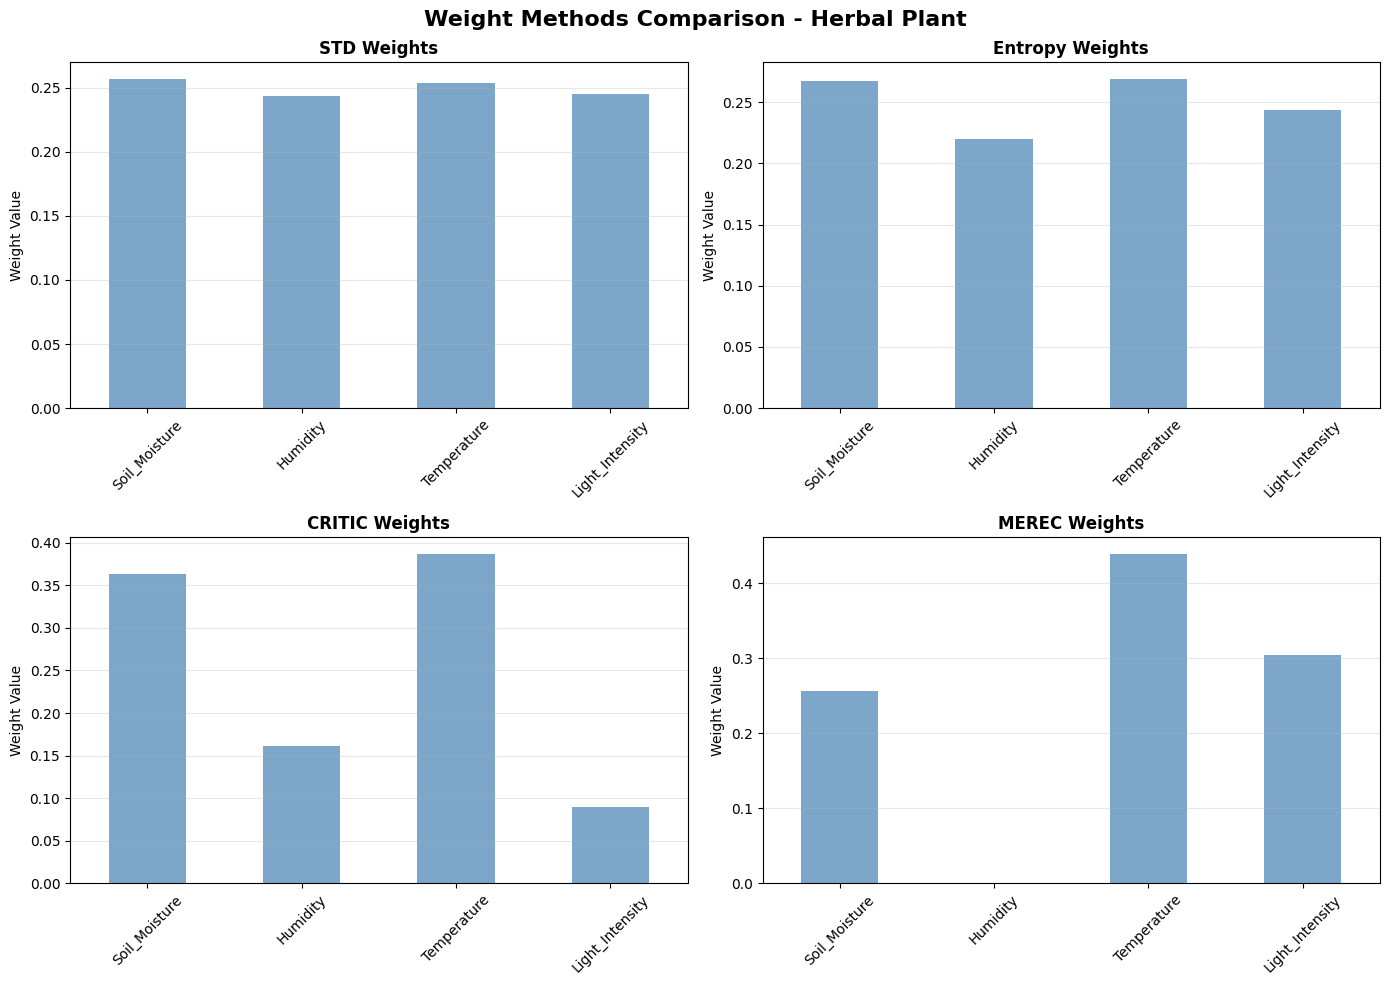

✓ Weights calculated and visualized!


In [9]:
# Weight calculation methods
def calc_weights_std(data):
    std_vals = data.std(ddof=0)
    return std_vals / std_vals.sum()

def calc_weights_entropy(data):
    n = len(data)
    pij = data / data.sum()
    pij = pij.replace(0, 1e-10)
    entropy = -(1 / np.log(n)) * (pij * np.log(pij)).sum()
    divergence = 1 - entropy
    return divergence / divergence.sum()

def calc_weights_critic(data):
    std_vals = data.std(ddof=0)
    corr_matrix = data.corr().abs()
    corr_sum = corr_matrix.sum() - 1
    critic_w = std_vals * corr_sum
    return critic_w / critic_w.sum()

def calc_weights_merec(data):
    n_alt = len(data)
    n_crit = len(data.columns)
    removal_effects = []
    
    for j in range(n_crit):
        cols_except_j = [col for col in data.columns if col != data.columns[j]]
        if len(cols_except_j) > 0:
            data_without_j = data[cols_except_j]
            perf_without_j = data_without_j.sum(axis=1) / len(cols_except_j)
            removal_effect = np.log(perf_without_j.sum() / n_alt)
        else:
            removal_effect = 0
        removal_effects.append(removal_effect)
    
    removal_effects = np.array(removal_effects)
    removal_effects = removal_effects - removal_effects.min()
    if removal_effects.sum() > 0:
        return pd.Series(removal_effects / removal_effects.sum(), index=data.columns)
    return pd.Series(np.ones(n_crit) / n_crit, index=data.columns)

# Calculate all weights
print("\n" + "=" * 80)
print("CALCULATING OBJECTIVE WEIGHTS (4 Methods)")
print("=" * 80)

w_std = calc_weights_std(X_normalized)
w_entropy = calc_weights_entropy(X_normalized)
w_critic = calc_weights_critic(X_normalized)
w_merec = calc_weights_merec(X_normalized)

weights_df = pd.DataFrame({
    'STD': w_std,
    'Entropy': w_entropy,
    'CRITIC': w_critic,
    'MEREC': w_merec
})

w_compromise = weights_df.mean(axis=1)
w_compromise = w_compromise / w_compromise.sum()
weights_df['Compromise'] = w_compromise

print("\nWeight Summary:")
print(weights_df)

# Visualization
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Weight Methods Comparison - Herbal Plant', fontsize=16, fontweight='bold')

for idx, method in enumerate(['STD', 'Entropy', 'CRITIC', 'MEREC']):
    ax = axes[idx // 2, idx % 2]
    weights_df[method].plot(kind='bar', ax=ax, color='steelblue', alpha=0.7)
    ax.set_title(f'{method} Weights', fontweight='bold')
    ax.set_ylabel('Weight Value')
    ax.grid(axis='y', alpha=0.3)
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print("✓ Weights calculated and visualized!")


APPLYING 4 MCDM SCORING METHODS

Top 20 Plants by MCDM Ranking:
     Index  Health_Status  MABAC_Rank  MARCOS_Rank  COCOCOMET_Rank
116    116              1           1            1               1
273    273              0           2            2               2
411    411              0           3            3               3
435    435              0           4            4               5
462    462              0           5            5               4
445    445              1           6            6               7
73      73              0           7            7               8
383    383              1           8            8               6
256    256              0           9            9               9
412    412              0          10           10              10
264    264              1          11           11              27
358    358              0          12           12              11
483    483              1          13           13              

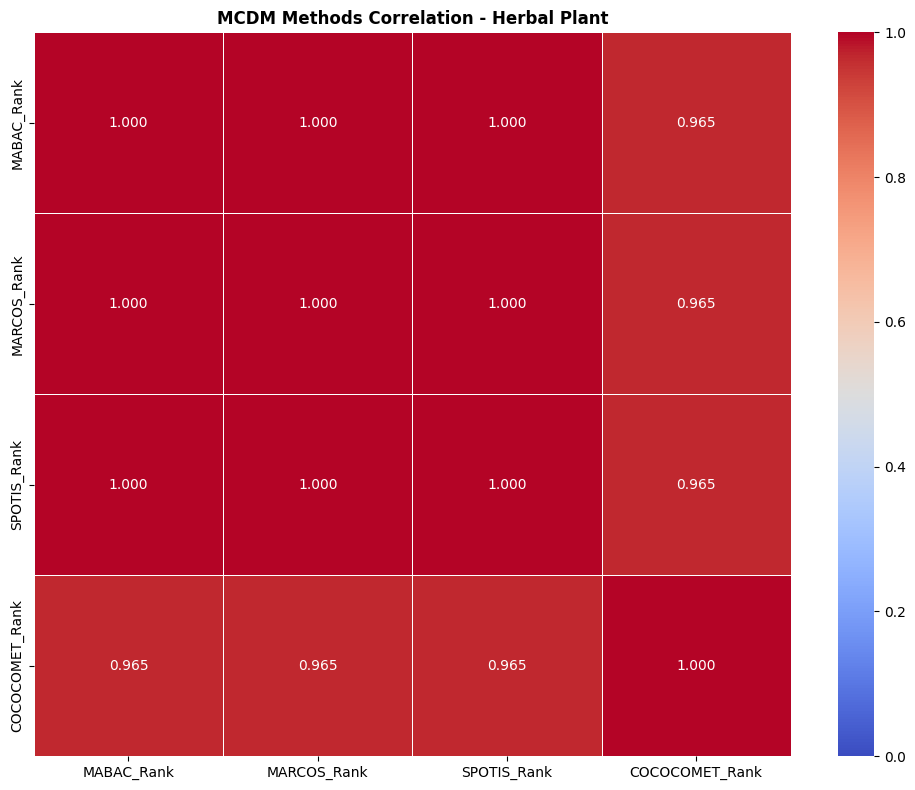

✓ MCDM scoring methods applied!


In [10]:
# MCDM Scoring Methods
def mabac_method(norm_data, weights):
    v = norm_data.copy()
    for col in norm_data.columns:
        v[col] = weights[col] * (norm_data[col] + 1)
    
    border_areas = {col: np.exp(np.log(v[col]).mean()) for col in norm_data.columns}
    
    scores = []
    for i in range(len(norm_data)):
        score = sum(v.loc[i, col] - border_areas[col] for col in norm_data.columns)
        scores.append(score)
    return np.array(scores)

def marcos_method(norm_data, weights):
    ideal_row = pd.Series(np.ones(len(norm_data.columns)), index=norm_data.columns)
    anti_ideal_row = pd.Series(np.zeros(len(norm_data.columns)), index=norm_data.columns)
    
    weighted_ideal = (ideal_row * weights).sum()
    weighted_anti_ideal = (anti_ideal_row * weights).sum()
    
    scores = []
    for i in range(len(norm_data)):
        weighted_sum = (norm_data.iloc[i] * weights).sum()
        k_plus = weighted_sum / weighted_ideal if weighted_ideal != 0 else 0
        k_minus = weighted_sum / weighted_anti_ideal if weighted_anti_ideal != 0 else 0
        scores.append(k_plus + k_minus)
    return np.array(scores)

def spotis_method(norm_data, weights):
    scores = []
    for i in range(len(norm_data)):
        distance = sum(weights[col] * abs(norm_data.loc[i, col] - 1.0) for col in norm_data.columns)
        scores.append(distance)
    return np.array(scores)

def cococomet_method(norm_data, weights, lam=0.5):
    s_power = []
    for i in range(len(norm_data)):
        sp = 1.0
        for col in norm_data.columns:
            sp *= (norm_data.loc[i, col] ** weights[col])
        s_power.append(sp)
    s_power = np.array(s_power)
    
    s_linear = np.array([sum(weights[col] * norm_data.loc[i, col] for col in norm_data.columns) 
                         for i in range(len(norm_data))])
    
    s_power_norm = s_power / (s_power.max() + 1e-10)
    s_linear_norm = s_linear / (s_linear.max() + 1e-10)
    
    return lam * s_power_norm + (1 - lam) * s_linear_norm

# Apply all methods
print("\n" + "=" * 80)
print("APPLYING 4 MCDM SCORING METHODS")
print("=" * 80)

mabac_scores = mabac_method(X_normalized, w_compromise)
mabac_ranks = (len(mabac_scores) + 1) - pd.Series(mabac_scores).rank().values

marcos_scores = marcos_method(X_normalized, w_compromise)
marcos_ranks = (len(marcos_scores) + 1) - pd.Series(marcos_scores).rank().values

spotis_dist = spotis_method(X_normalized, w_compromise)
spotis_ranks = pd.Series(spotis_dist).rank().values

cococomet_scores = cococomet_method(X_normalized, w_compromise)
cococomet_ranks = (len(cococomet_scores) + 1) - pd.Series(cococomet_scores).rank().values

# Combine results
mcdm_results = pd.DataFrame({
    'Index': range(len(X_normalized)),
    'Health_Status': df_mcdm['Label'].values,
    'PHI': df_mcdm['PHI'].values,
    'MABAC_Score': mabac_scores,
    'MABAC_Rank': mabac_ranks.astype(int),
    'MARCOS_Score': marcos_scores,
    'MARCOS_Rank': marcos_ranks.astype(int),
    'SPOTIS_Rank': spotis_ranks.astype(int),
    'COCOCOMET_Score': cococomet_scores,
    'COCOCOMET_Rank': cococomet_ranks.astype(int)
})

print("\nTop 20 Plants by MCDM Ranking:")
print(mcdm_results.nsmallest(20, 'MABAC_Rank')[['Index', 'Health_Status', 'MABAC_Rank', 'MARCOS_Rank', 'COCOCOMET_Rank']])

# Correlation between methods
rank_cols = ['MABAC_Rank', 'MARCOS_Rank', 'SPOTIS_Rank', 'COCOCOMET_Rank']
print("\n\nSpearman Correlations between Methods:")
corr_matrix = mcdm_results[rank_cols].corr('spearman')
print(corr_matrix)

# Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='coolwarm', center=0.5, vmin=0, vmax=1, linewidths=0.5)
plt.title('MCDM Methods Correlation - Herbal Plant', fontweight='bold')
plt.tight_layout()
plt.show()

print("✓ MCDM scoring methods applied!")


MACHINE LEARNING - PLANT HEALTH PREDICTION

Training set: 400 | Test set: 100
Healthy plants: 282 | Unhealthy: 218

[1/4] Training Logistic Regression...
[2/4] Training Random Forest...
[3/4] Training Gradient Boosting...
[4/4] Training Neural Network...


Model Performance Comparison:
                     Accuracy  Precision    Recall        F1   ROC-AUC
Logistic Regression      0.87   0.848485  0.949153  0.896000  0.959901
Random Forest            0.95   0.965517  0.949153  0.957265  0.988012
Gradient Boosting        0.95   0.965517  0.949153  0.957265  0.995039
Neural Network           0.97   0.982759  0.966102  0.974359  0.998760

🏆 Best Model: Neural Network (F1 = 0.9744)


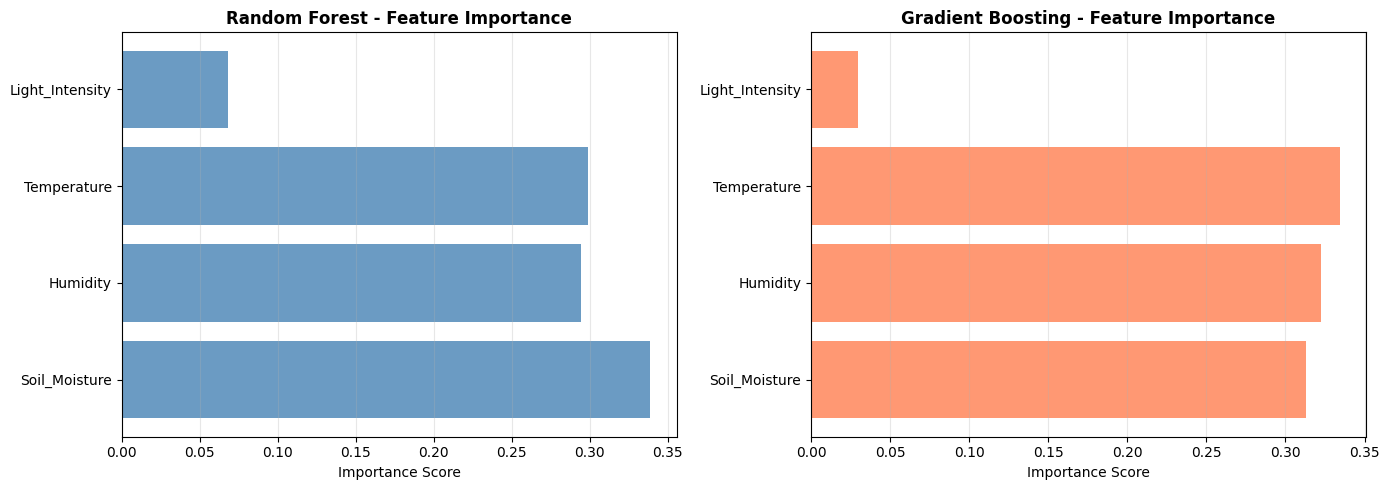

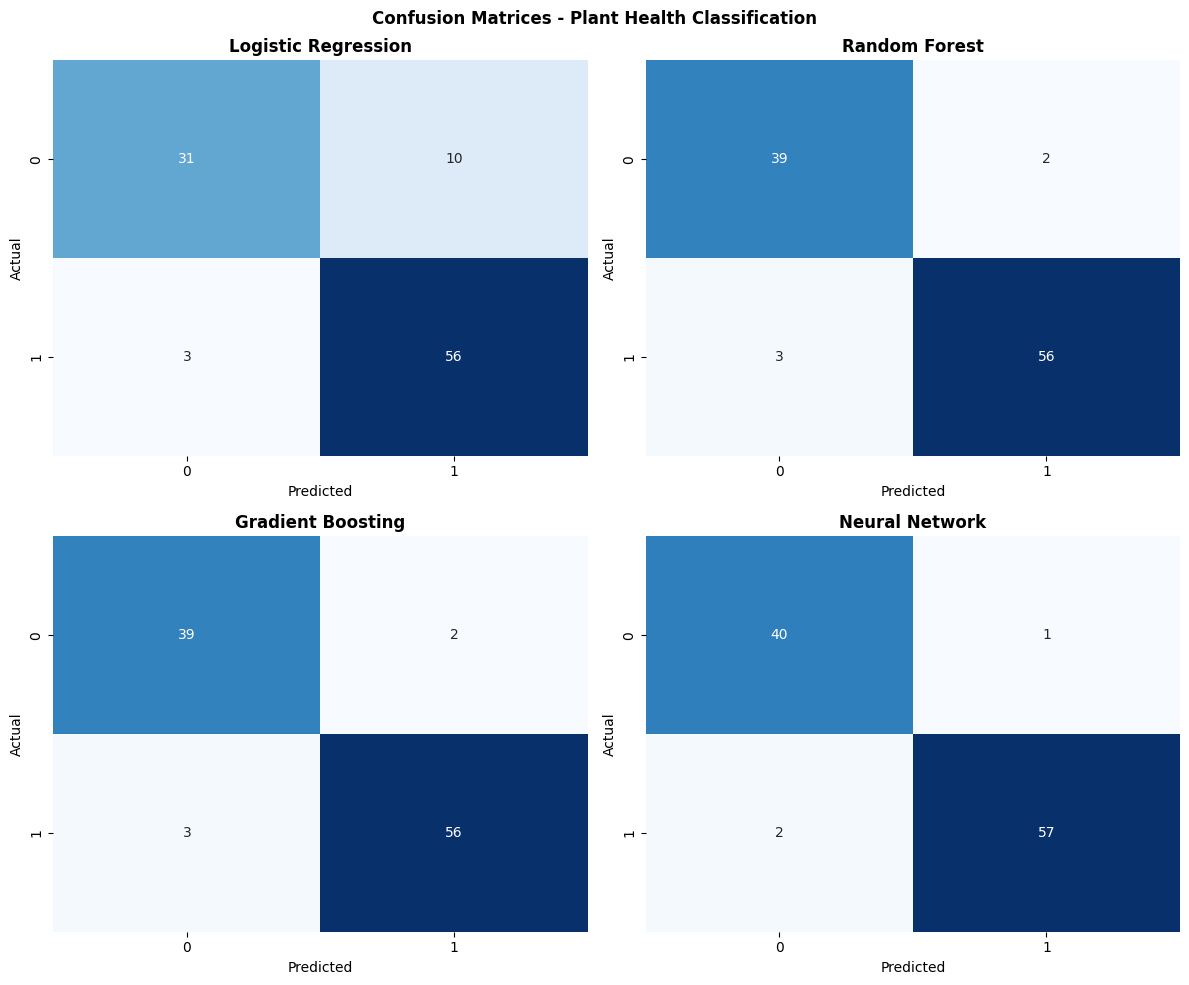


✓ Plant health classification models trained and evaluated!


In [11]:
# Machine Learning: Plant Health Classification
print("\n" + "=" * 80)
print("MACHINE LEARNING - PLANT HEALTH PREDICTION")
print("=" * 80)

y_health = df_mcdm['Label'].values
X_train, X_test, y_train, y_test = train_test_split(X_normalized, y_health, test_size=0.2, random_state=42)

print(f"\nTraining set: {len(X_train)} | Test set: {len(X_test)}")
print(f"Healthy plants: {sum(y_health)} | Unhealthy: {len(y_health) - sum(y_health)}")

# Train 4 classification models
models = {}
results = {}

# 1. Logistic Regression
print("\n[1/4] Training Logistic Regression...")
lr = LogisticRegression(random_state=42, max_iter=1000)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)
models['Logistic Regression'] = lr
results['Logistic Regression'] = {
    'Accuracy': accuracy_score(y_test, y_pred_lr),
    'Precision': precision_score(y_test, y_pred_lr),
    'Recall': recall_score(y_test, y_pred_lr),
    'F1': f1_score(y_test, y_pred_lr),
    'ROC-AUC': roc_auc_score(y_test, lr.predict_proba(X_test)[:, 1])
}

# 2. Random Forest Classifier
print("[2/4] Training Random Forest...")
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
models['Random Forest'] = rf
results['Random Forest'] = {
    'Accuracy': accuracy_score(y_test, y_pred_rf),
    'Precision': precision_score(y_test, y_pred_rf),
    'Recall': recall_score(y_test, y_pred_rf),
    'F1': f1_score(y_test, y_pred_rf),
    'ROC-AUC': roc_auc_score(y_test, rf.predict_proba(X_test)[:, 1])
}

# 3. Gradient Boosting Classifier
print("[3/4] Training Gradient Boosting...")
gb = GradientBoostingClassifier(n_estimators=100, random_state=42)
gb.fit(X_train, y_train)
y_pred_gb = gb.predict(X_test)
models['Gradient Boosting'] = gb
results['Gradient Boosting'] = {
    'Accuracy': accuracy_score(y_test, y_pred_gb),
    'Precision': precision_score(y_test, y_pred_gb),
    'Recall': recall_score(y_test, y_pred_gb),
    'F1': f1_score(y_test, y_pred_gb),
    'ROC-AUC': roc_auc_score(y_test, gb.predict_proba(X_test)[:, 1])
}

# 4. Neural Network
print("[4/4] Training Neural Network...")
nn = MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=500, random_state=42)
nn.fit(X_train, y_train)
y_pred_nn = nn.predict(X_test)
models['Neural Network'] = nn
results['Neural Network'] = {
    'Accuracy': accuracy_score(y_test, y_pred_nn),
    'Precision': precision_score(y_test, y_pred_nn),
    'Recall': recall_score(y_test, y_pred_nn),
    'F1': f1_score(y_test, y_pred_nn),
    'ROC-AUC': roc_auc_score(y_test, nn.predict_proba(X_test)[:, 1])
}

# Display results
results_df = pd.DataFrame(results).T
print("\n\nModel Performance Comparison:")
print("=" * 80)
print(results_df)

best_model = results_df['F1'].idxmax()
print(f"\n🏆 Best Model: {best_model} (F1 = {results_df.loc[best_model, 'F1']:.4f})")

# Feature Importance
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

rf_importance = rf.feature_importances_
axes[0].barh(criteria_columns, rf_importance, color='steelblue', alpha=0.8)
axes[0].set_xlabel('Importance Score')
axes[0].set_title('Random Forest - Feature Importance', fontweight='bold')
axes[0].grid(axis='x', alpha=0.3)

gb_importance = gb.feature_importances_
axes[1].barh(criteria_columns, gb_importance, color='coral', alpha=0.8)
axes[1].set_xlabel('Importance Score')
axes[1].set_title('Gradient Boosting - Feature Importance', fontweight='bold')
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

# Confusion Matrices
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle('Confusion Matrices - Plant Health Classification', fontweight='bold')

predictions = [
    (y_pred_lr, 'Logistic Regression'),
    (y_pred_rf, 'Random Forest'),
    (y_pred_gb, 'Gradient Boosting'),
    (y_pred_nn, 'Neural Network')
]

for idx, (y_pred, model_name) in enumerate(predictions):
    ax = axes[idx // 2, idx % 2]
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, cbar=False)
    ax.set_title(f'{model_name}', fontweight='bold')
    ax.set_ylabel('Actual')
    ax.set_xlabel('Predicted')

plt.tight_layout()
plt.show()

print("\n✓ Plant health classification models trained and evaluated!")

In [12]:
print("\n" + "=" * 80)
print("HERBAL PLANT HEALTH MONITORING - FINAL SUMMARY")
print("=" * 80)

print("\n📊 MCDM FRAMEWORK:")
print(f"  ✓ Data analyzed: {len(X_normalized)} plant observations")
print(f"  ✓ Criteria evaluated: {len(criteria_columns)} sensors")
print(f"  ✓ Weight methods: 4 (STD, Entropy, CRITIC, MEREC) + Compromise")
print(f"  ✓ Scoring methods: 4 (MABAC, MARCOS, SPOTIS, COCOCOMET)")

print("\n🌱 SENSOR CRITERIA:")
for criterion, ctype in criteria_types.items():
    print(f"  • {criterion:20s}: {ctype:10s}")

print("\n🤖 MACHINE LEARNING RESULTS:")
print(f"  ✓ Best Classification Model: {best_model}")
for metric in ['Accuracy', 'Precision', 'Recall', 'F1', 'ROC-AUC']:
    print(f"    {metric:12s}: {results_df.loc[best_model, metric]:.4f}")

print("\n📈 KEY INSIGHTS:")
print("  1. MCDM methods rank plants by environmental suitability")
print("  2. ML models predict plant health status (Healthy/Unhealthy)")
print("  3. High correlation between MCDM methods indicates stable rankings")
print("  4. Feature importance reveals which sensors matter most for health")

print("\n🎯 PRACTICAL APPLICATIONS:")
print("  • Early disease detection in indoor herb farms")
print("  • Sensor-based precision agriculture for controlled environments")
print("  • Automated irrigation/lighting optimization")
print("  • Quality control for commercial herb production")

print("\n" + "=" * 80)
print("✓ ANALYSIS COMPLETE!")
print("=" * 80)


HERBAL PLANT HEALTH MONITORING - FINAL SUMMARY

📊 MCDM FRAMEWORK:
  ✓ Data analyzed: 500 plant observations
  ✓ Criteria evaluated: 4 sensors
  ✓ Weight methods: 4 (STD, Entropy, CRITIC, MEREC) + Compromise
  ✓ Scoring methods: 4 (MABAC, MARCOS, SPOTIS, COCOCOMET)

🌱 SENSOR CRITERIA:
  • Soil_Moisture       : profit    
  • Humidity            : cost      
  • Temperature         : cost      
  • Light_Intensity     : profit    

🤖 MACHINE LEARNING RESULTS:
  ✓ Best Classification Model: Neural Network
    Accuracy    : 0.9700
    Precision   : 0.9828
    Recall      : 0.9661
    F1          : 0.9744
    ROC-AUC     : 0.9988

📈 KEY INSIGHTS:
  1. MCDM methods rank plants by environmental suitability
  2. ML models predict plant health status (Healthy/Unhealthy)
  3. High correlation between MCDM methods indicates stable rankings
  4. Feature importance reveals which sensors matter most for health

🎯 PRACTICAL APPLICATIONS:
  • Early disease detection in indoor herb farms
  • Sensor-ba